## Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_auc_score
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping
import time

print("All libraries loaded successfully")
print("TensorFlow version:", tf.__version__)

All libraries loaded successfully
TensorFlow version: 2.21.0


## Generate realistic sensor data

In [26]:
np.random.seed(42)

n_points = 2000
time_steps = np.arange(n_points)

# Clean periodic signal
normal_signal = (
    10 * np.sin(2 * np.pi * time_steps / 50) +
    np.random.normal(0, 0.3, n_points)
)

labels = np.zeros(n_points, dtype=int)
signal = normal_signal.copy()

# Inject only point spikes — easy for all models to detect
n_anomalies = 40
anomaly_indices = np.sort(np.random.choice(
    np.arange(100, n_points - 100), size=n_anomalies, replace=False
))

for idx in anomaly_indices:
    signal[idx] += np.random.choice([-1, 1]) * np.random.uniform(12, 18)
    labels[idx] = 1

df = pd.DataFrame({"timestamp": time_steps, "value": signal, "anomaly": labels})

# Rescale
scaler = MinMaxScaler()
values_scaled = scaler.fit_transform(df[["value"]])

print(f"Dataset shape  : {df.shape}")
print(f"Normal points  : {(labels==0).sum()}")
print(f"Anomaly points : {(labels==1).sum()}")
print(f"Signal range   : [{signal.min():.1f}, {signal.max():.1f}]")
print(f"Anomaly range  : [{signal[labels==1].min():.1f}, {signal[labels==1].max():.1f}]")

Dataset shape  : (2000, 3)
Normal points  : 1960
Anomaly points : 40
Signal range   : [-26.5, 24.5]
Anomaly range  : [-26.5, 24.5]


## Visualise the sensor data

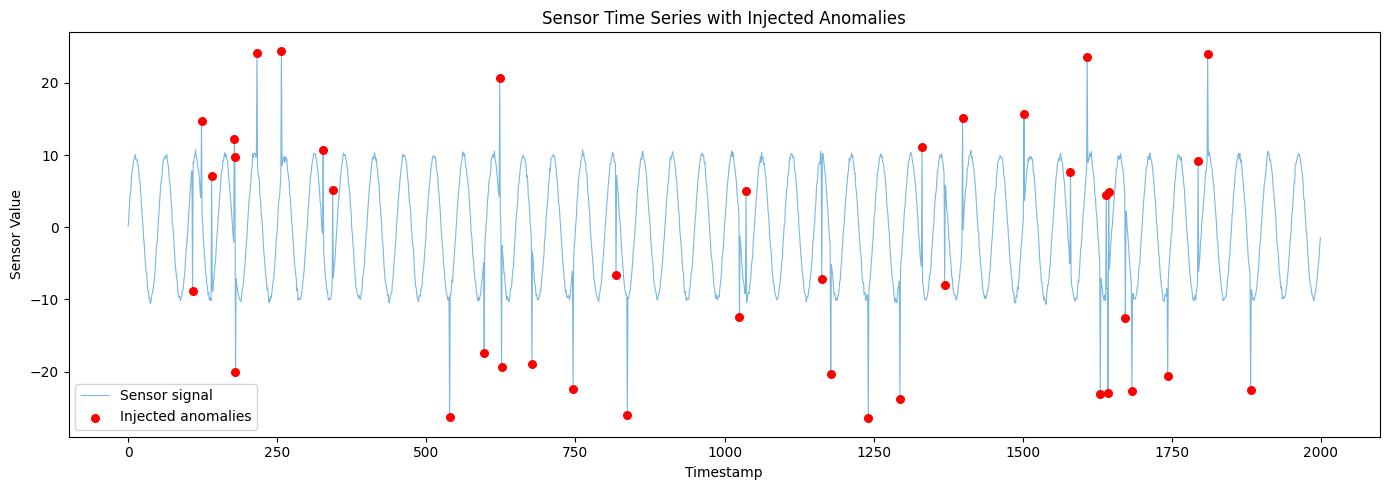

In [27]:
plt.figure(figsize=(14, 5))
plt.plot(df["timestamp"], df["value"], color="#7bb8e0", linewidth=0.8, label="Sensor signal")
plt.scatter(
    df[df["anomaly"] == 1]["timestamp"],
    df[df["anomaly"] == 1]["value"],
    color="red", s=30, zorder=5, label="Injected anomalies"
)
plt.title("Sensor Time Series with Injected Anomalies")
plt.xlabel("Timestamp")
plt.ylabel("Sensor Value")
plt.legend()
plt.tight_layout()
plt.show()

## Method 1: Z-Score anomaly detection

Z-Score AUROC: 0.8549
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99      1960
     Anomaly       1.00      0.33      0.49        40

    accuracy                           0.99      2000
   macro avg       0.99      0.66      0.74      2000
weighted avg       0.99      0.99      0.98      2000



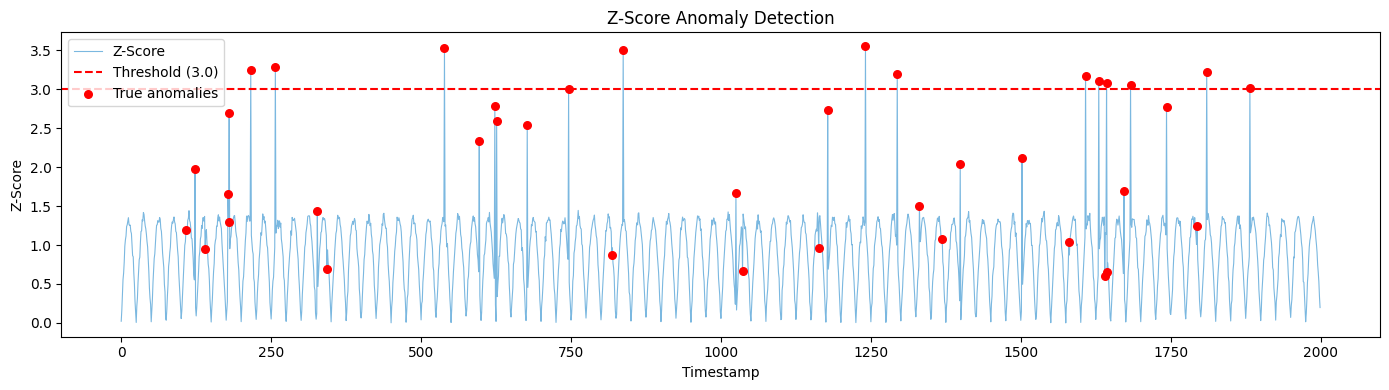

In [28]:
def zscore_detection(values, threshold=3.0):
    mean = np.mean(values)
    std  = np.std(values)
    scores = np.abs((values - mean) / std)
    predictions = (scores > threshold).astype(int)
    return scores, predictions

zscore_scores, zscore_preds = zscore_detection(df["value"].values, threshold=3.0)

zscore_auroc = roc_auc_score(df["anomaly"], zscore_scores)
print(f"Z-Score AUROC: {zscore_auroc:.4f}")
print(classification_report(df["anomaly"], zscore_preds, target_names=["Normal", "Anomaly"]))

plt.figure(figsize=(14, 4))
plt.plot(df["timestamp"], zscore_scores, color="#7bb8e0", linewidth=0.8, label="Z-Score")
plt.axhline(3.0, color="red", linestyle="--", label="Threshold (3.0)")
plt.scatter(df[df["anomaly"]==1]["timestamp"], zscore_scores[df["anomaly"]==1],
            color="red", s=30, zorder=5, label="True anomalies")
plt.title("Z-Score Anomaly Detection")
plt.xlabel("Timestamp")
plt.ylabel("Z-Score")
plt.legend()
plt.tight_layout()
plt.show()

##  Method 2: Isolation Forest

Isolation Forest AUROC: 0.8106
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1960
     Anomaly       0.56      0.70      0.62        40

    accuracy                           0.98      2000
   macro avg       0.78      0.84      0.81      2000
weighted avg       0.99      0.98      0.98      2000



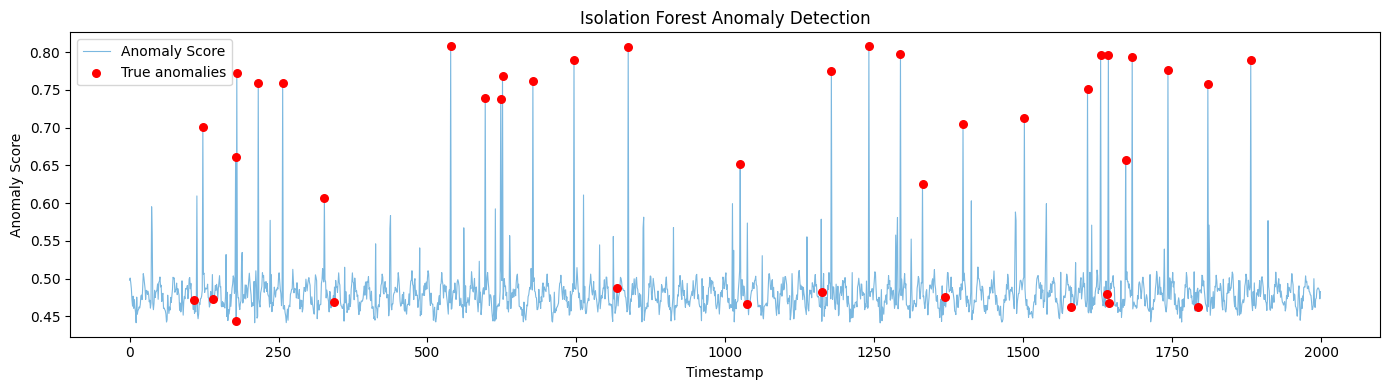

In [29]:
scaler = MinMaxScaler()
values_scaled = scaler.fit_transform(df[["value"]])

iso = IsolationForest(n_estimators=100, contamination=0.025, random_state=42)
iso.fit(values_scaled)

iso_scores = -iso.score_samples(values_scaled)
iso_preds  = (iso.predict(values_scaled) == -1).astype(int)

iso_auroc = roc_auc_score(df["anomaly"], iso_scores)
print(f"Isolation Forest AUROC: {iso_auroc:.4f}")
print(classification_report(df["anomaly"], iso_preds, target_names=["Normal", "Anomaly"]))

plt.figure(figsize=(14, 4))
plt.plot(df["timestamp"], iso_scores, color="#7bb8e0", linewidth=0.8, label="Anomaly Score")
plt.scatter(df[df["anomaly"]==1]["timestamp"], iso_scores[df["anomaly"]==1],
            color="red", s=30, zorder=5, label="True anomalies")
plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("Timestamp")
plt.ylabel("Anomaly Score")
plt.legend()
plt.tight_layout()
plt.show()

## Method 3: LSTM Autoencoder

In [38]:
SEQ_LEN = 20

def create_pred_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

normal_values = scaler.transform(df[df["anomaly"]==0][["value"]].values)
X_train, y_train = create_pred_sequences(normal_values, SEQ_LEN)

X_full_pred, y_full_pred = create_pred_sequences(values_scaled, SEQ_LEN)

print(f"Training sequences : {X_train.shape}")
print(f"Training targets   : {y_train.shape}")

lstm_model = Sequential([
    LSTM(64, input_shape=(SEQ_LEN, 1), return_sequences=True),
    LSTM(32, return_sequences=False),
    Dense(16, activation="relu"),
    Dense(1)
])

lstm_model.compile(optimizer="adam", loss="mse")
lstm_model.summary()

Training sequences : (1940, 20, 1)
Training targets   : (1940, 1)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_14 (LSTM)                       │ (None, 20, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_15 (LSTM)                       │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

## Train LSTM

Training LSTM prediction model...
Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.0400 - val_loss: 0.0142
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0120 - val_loss: 0.0064
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0012 - val_loss: 9.5517e-05
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 1.1489e-04 - val_loss: 7.4915e-05
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 1.1124e-04 - val_loss: 1.0904e-04
Epoch 6/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.2466e-04 - val_loss: 1.3445e-04
Epoch 7/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.1803e-04 - val_loss: 6.5710e-05
Epoch 8/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1.2307e-04 - val_loss: 1.0137e-04
Epoch 9/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.2069e-04 - val_loss: 8.2417e-05
Epoch 10/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1.3694e-04 - val_loss: 6.6055e-05
Epoch 11/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - l

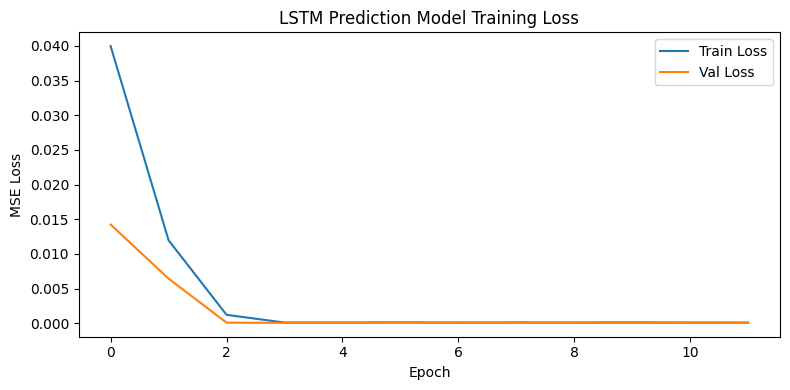

In [39]:
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

print("Training LSTM prediction model...")
history = lstm_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("LSTM Prediction Model Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

## LSTM evaluation

LSTM Prediction AUROC: 1.0000
Threshold: 0.044367
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98      1940
     Anomaly       0.40      1.00      0.58        40

    accuracy                           0.97      1980
   macro avg       0.70      0.98      0.78      1980
weighted avg       0.99      0.97      0.98      1980



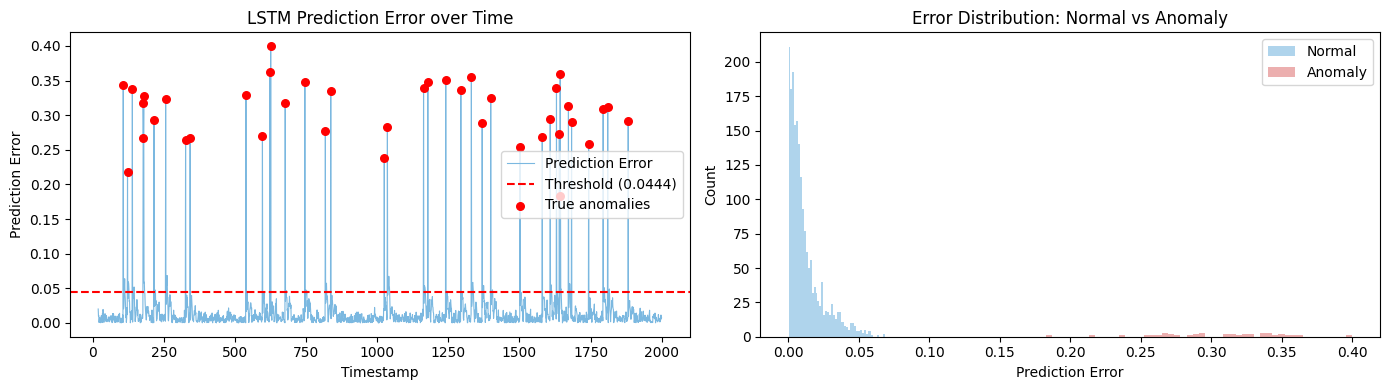

In [40]:
# Predict and compute errors
y_pred = lstm_model.predict(X_full_pred, verbose=0).flatten()
lstm_errors = np.abs(y_pred - y_full_pred.flatten())

# Align labels
lstm_labels = df["anomaly"].values[SEQ_LEN:]

lstm_auroc = roc_auc_score(lstm_labels, lstm_errors)
threshold  = np.percentile(lstm_errors, 95)
lstm_preds = (lstm_errors > threshold).astype(int)

print(f"LSTM Prediction AUROC: {lstm_auroc:.4f}")
print(f"Threshold: {threshold:.6f}")
print(classification_report(lstm_labels, lstm_preds,
                             target_names=["Normal", "Anomaly"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(df["timestamp"][SEQ_LEN:], lstm_errors,
             color="#7bb8e0", linewidth=0.8, label="Prediction Error")
axes[0].axhline(threshold, color="red", linestyle="--",
                label=f"Threshold ({threshold:.4f})")
anomaly_mask = lstm_labels == 1
axes[0].scatter(
    df["timestamp"].values[SEQ_LEN:][anomaly_mask],
    lstm_errors[anomaly_mask],
    color="red", s=30, zorder=5, label="True anomalies"
)
axes[0].set_title("LSTM Prediction Error over Time")
axes[0].set_xlabel("Timestamp")
axes[0].set_ylabel("Prediction Error")
axes[0].legend()

axes[1].hist(lstm_errors[lstm_labels==0], bins=50, alpha=0.6,
             color="#7bb8e0", label="Normal")
axes[1].hist(lstm_errors[lstm_labels==1], bins=50, alpha=0.6,
             color="#e07b7b", label="Anomaly")
axes[1].set_title("Error Distribution: Normal vs Anomaly")
axes[1].set_xlabel("Prediction Error")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

## Final model comparison

Final Model Comparison
LSTM Autoencoder      : AUROC 1.0000
Z-Score               : AUROC 0.8552
Isolation Forest      : AUROC 0.8100


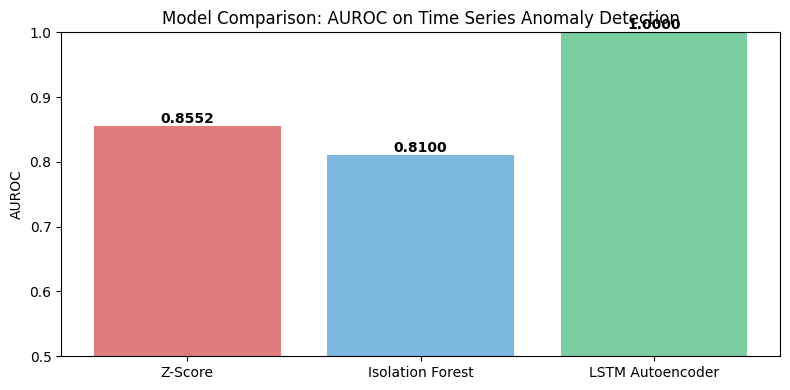

In [41]:
# Align all labels for fair comparison
aligned_labels = df["anomaly"].values[SEQ_LEN:]
aligned_zscore  = zscore_scores[SEQ_LEN:]
aligned_iso     = iso_scores[SEQ_LEN:]

zscore_auroc_aligned = roc_auc_score(aligned_labels, aligned_zscore)
iso_auroc_aligned    = roc_auc_score(aligned_labels, aligned_iso)

results = {
    "Z-Score":           zscore_auroc_aligned,
    "Isolation Forest":  iso_auroc_aligned,
    "LSTM Autoencoder":  lstm_auroc
}

print("Final Model Comparison")
print("=" * 40)
for model_name, auroc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{model_name:<22}: AUROC {auroc:.4f}")

plt.figure(figsize=(8, 4))
colors = ["#e07b7b", "#7bb8e0", "#7bcea0"]
bars = plt.bar(results.keys(), results.values(), color=colors)
plt.ylim(0.5, 1.0)
plt.title("Model Comparison: AUROC on Time Series Anomaly Detection")
plt.ylabel("AUROC")
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.005,
             f"{val:.4f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()